In [1]:
from torchvision import transforms
from transformers import FlavaModel,AutoProcessor,CLIPProcessor,CLIPModel
from torch.utils.data import DataLoader
import torch
from sklearn.utils.class_weight import compute_class_weight
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from torch.nn.modules.loss import BCEWithLogitsLoss,CrossEntropyLoss
import numpy as np
from modules.inference import MemeDetector
from modules.model import Train,Test,HeadClassifierFLAVAModel
from modules.data_preparation import split_flava_embeddings,FLAVACollateFunction,CreationFLAVADataset,CreationProcessedDataset
from modules.extraction import FLAVAExtractor
from sklearn.metrics import RocCurveDisplay,roc_auc_score,roc_curve
import matplotlib.pyplot as plt
import sys, os
from PIL import Image
sys.path.append(os.path.abspath(".."))

from CLIP_model.modules.data_preparation import CreationProcessedDataset as CreationClipDataset
from common_files import creation_dataframe,set_seed,seed_worker


In [2]:
seed=42
set_seed(seed=seed)

In [3]:
#creation of the dataframes
train_df=creation_dataframe("../data/train.jsonl")
val_df=creation_dataframe("../data/dev.jsonl")

In [4]:
#creation of the datasets used for the FLAVA forward
train_FLAVA_dataset=CreationFLAVADataset(train_df)
val_FLAVA_dataset=CreationFLAVADataset(val_df)

In [5]:
#processor used to process the input data before the FLAVA forward
processor=AutoProcessor.from_pretrained("facebook/flava-full")

In [6]:
flava_model=FlavaModel.from_pretrained("facebook/flava-full")
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))

In [7]:
batch_size=32
generator=torch.Generator()
generator.manual_seed(seed)
collate_function_object=FLAVACollateFunction(processor)

In [8]:
#creation of the dataloaders for the FLAVA forward and process of the input data
train_FLAVA_dataloader=DataLoader(train_FLAVA_dataset,collate_fn=collate_function_object.collate_fn,batch_size=batch_size,shuffle=False,generator=generator,worker_init_fn=seed_worker)
val_FLAVA_dataloader=DataLoader(val_FLAVA_dataset,collate_fn=collate_function_object.collate_fn,batch_size=batch_size,shuffle=False,generator=generator,worker_init_fn=seed_worker)

In [9]:
flava_extractor=FLAVAExtractor(flava_model=flava_model,device=device)

In [10]:
#extraction of the FLAVA embeddings
#train_flava_data=flava_extractor.get_embeddings(train_FLAVA_dataloader,"./modules/flava_embeddings","train")
#val_flava_data=flava_extractor.get_embeddings(train_FLAVA_dataloader,"./modules/flava_embeddings","val")

In [10]:
train_flava_embeddings=torch.load("./modules/flava_embeddings/train_flava_embeddings.pt")
val_flava_embeddings=torch.load("./modules/flava_embeddings/val_flava_embeddings.pt")

In [11]:
train_clip_embeddings=torch.load("../CLIP_model/modules/clip_embeddings/train_clip_embeddings.pt")
val_clip_embeddings=torch.load("../CLIP_model/modules/clip_embeddings/val_clip_embeddings.pt")

In [12]:
original_train_all_embeddings=train_flava_embeddings.copy()
original_train_all_embeddings.update(train_clip_embeddings)
val_all_embeddings=val_flava_embeddings.copy()
val_all_embeddings.update(val_clip_embeddings)

In [13]:
train_all_embeddings,test_all_embeddings=split_flava_embeddings(original_train_all_embeddings)

In [14]:
train_dataset=CreationProcessedDataset(train_all_embeddings)
val_dataset=CreationProcessedDataset(val_all_embeddings)
train_dataloader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,drop_last=True,generator=generator,worker_init_fn=seed_worker)
val_dataloader=DataLoader(val_dataset,batch_size=batch_size,shuffle=True,drop_last=True,generator=generator,worker_init_fn=seed_worker)

In [15]:
class_weight=compute_class_weight("balanced",classes=np.unique(train_df["label"]),y=train_all_embeddings["labels"].numpy())
class_weight=torch.tensor(class_weight, dtype=torch.float32)
print(class_weight)

tensor([0.7798, 1.3934])


In [16]:
#Training without CLIP embeddings and using FLAVA pooler embeddings
path="./train_savings/pooler_only_savings"
multimodal=False
with_clip=False
with_clip_image=False
with_clip_text=False
fc_layer_sizes=[384]
n_epochs=11
n_steps=len(train_dataloader)*n_epochs
lr=0.01
weight_decay=5e-4
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_image=with_clip_image,with_clip_text=with_clip_text)
num_warmup_steps=int(0.1*n_steps)
optimizer=AdamW(model.parameters(),lr=lr,weight_decay=weight_decay)
scheduler=get_linear_schedule_with_warmup(optimizer,num_warmup_steps=num_warmup_steps,num_training_steps=n_steps)
loss_fn=CrossEntropyLoss(weight=class_weight)
trainer=Train(model,loss_fn,optimizer,n_epochs,scheduler,device)
trainer.run_training(train_dataloader=train_dataloader,val_dataloader=val_dataloader,path=path,multimodal=multimodal,with_clip=with_clip)

2026-05-03 16:44:38.118 | INFO     | modules.model.train:run_training:99 - Epoch 0 :
2026-05-03 16:44:48.872 | INFO     | modules.model.train:run_training:196 - Epoch 0: Train Loss = 0.8388348416304489
2026-05-03 16:44:48.913 | INFO     | modules.model.train:run_training:197 - Epoch 0: Train Accuracy = 0.6413441422594143
2026-05-03 16:44:48.913 | INFO     | modules.model.train:run_training:198 - Epoch 0: Train F1 = 0.5020536177610315
2026-05-03 16:44:48.913 | INFO     | modules.model.train:run_training:200 - Epoch 0: Validation Loss = 0.9885224382082621
2026-05-03 16:44:48.913 | INFO     | modules.model.train:run_training:201 - Epoch 0: Validation Accuracy = 0.49583333333333335
2026-05-03 16:44:48.913 | INFO     | modules.model.train:run_training:202 - Epoch 0: Validation F1 = 0.32871402042711234
2026-05-03 16:44:49.189 | INFO     | modules.model.train:run_training:99 - Epoch 1 :
2026-05-03 16:44:55.501 | INFO     | modules.model.train:run_training:196 - Epoch 1: Train Loss = 0.7153291

0.32871402042711234

In [17]:
#Training with CLIP embeddings and using FLAVA pooler embeddings
path="./train_savings/pooler_with_clip_savings"
multimodal=False
with_clip=True
with_clip_image=True
with_clip_text=True
fc_layer_sizes=[640]
n_epochs=11
n_steps=len(train_dataloader)*n_epochs
lr=0.01
weight_decay=5e-4
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_image=with_clip_image,with_clip_text=with_clip_text)
num_warmup_steps=int(0.1*n_steps)
optimizer=AdamW(model.parameters(),lr=lr,weight_decay=weight_decay)
scheduler=get_linear_schedule_with_warmup(optimizer,num_warmup_steps=num_warmup_steps,num_training_steps=n_steps)
loss_fn=CrossEntropyLoss(weight=class_weight)
trainer=Train(model,loss_fn,optimizer,n_epochs,scheduler,device)
trainer.run_training(train_dataloader=train_dataloader,val_dataloader=val_dataloader,path=path,multimodal=multimodal,with_clip=with_clip)

2026-05-03 16:46:12.211 | INFO     | modules.model.train:run_training:99 - Epoch 0 :
2026-05-03 16:46:17.066 | INFO     | modules.model.train:run_training:196 - Epoch 0: Train Loss = 0.7153377969394668
2026-05-03 16:46:17.067 | INFO     | modules.model.train:run_training:197 - Epoch 0: Train Accuracy = 0.46940376569037656
2026-05-03 16:46:17.067 | INFO     | modules.model.train:run_training:198 - Epoch 0: Train F1 = 0.47558034957770107
2026-05-03 16:46:17.067 | INFO     | modules.model.train:run_training:200 - Epoch 0: Validation Loss = 0.6771579504013061
2026-05-03 16:46:17.067 | INFO     | modules.model.train:run_training:201 - Epoch 0: Validation Accuracy = 0.49583333333333335
2026-05-03 16:46:17.070 | INFO     | modules.model.train:run_training:202 - Epoch 0: Validation F1 = 0.4598728942012039
2026-05-03 16:46:17.133 | INFO     | modules.model.train:run_training:99 - Epoch 1 :
2026-05-03 16:46:20.996 | INFO     | modules.model.train:run_training:196 - Epoch 1: Train Loss = 0.692783

0.5966329966329966

In [18]:
#Training without CLIP embeddings and using FLAVA multimodal embeddings
path="./train_savings/multimodal_only_savings"
multimodal=True
with_clip=False
with_clip_image=False
with_clip_text=False
fc_layer_sizes=[384]
n_epochs=11
n_steps=len(train_dataloader)*n_epochs
lr=0.01
weight_decay=5e-4
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_image=with_clip_image,with_clip_text=with_clip_text)
num_warmup_steps=int(0.1*n_steps)
optimizer=AdamW(model.parameters(),lr=lr,weight_decay=weight_decay)
scheduler=get_linear_schedule_with_warmup(optimizer,num_warmup_steps=num_warmup_steps,num_training_steps=n_steps)
loss_fn=CrossEntropyLoss(weight=class_weight)
trainer=Train(model,loss_fn,optimizer,n_epochs,scheduler,device)
trainer.run_training(train_dataloader=train_dataloader,val_dataloader=val_dataloader,path=path,multimodal=multimodal,with_clip=with_clip)

2026-05-03 16:47:06.336 | INFO     | modules.model.train:run_training:99 - Epoch 0 :
2026-05-03 16:47:09.473 | INFO     | modules.model.train:run_training:196 - Epoch 0: Train Loss = 0.7486771429931768
2026-05-03 16:47:09.473 | INFO     | modules.model.train:run_training:197 - Epoch 0: Train Accuracy = 0.3946129707112971
2026-05-03 16:47:09.473 | INFO     | modules.model.train:run_training:198 - Epoch 0: Train F1 = 0.3365703572607894
2026-05-03 16:47:09.473 | INFO     | modules.model.train:run_training:200 - Epoch 0: Validation Loss = 0.6628321409225464
2026-05-03 16:47:09.479 | INFO     | modules.model.train:run_training:201 - Epoch 0: Validation Accuracy = 0.5041666666666667
2026-05-03 16:47:09.479 | INFO     | modules.model.train:run_training:202 - Epoch 0: Validation F1 = 0.3535569105691057
2026-05-03 16:47:09.485 | INFO     | modules.model.train:run_training:99 - Epoch 1 :
2026-05-03 16:47:12.697 | INFO     | modules.model.train:run_training:196 - Epoch 1: Train Loss = 0.695373361

0.4848954116059379

In [44]:
#Training with CLIP embeddings and using FLAVA multimodal embeddings
path="./train_savings/multimodal_with_clip_savings"
multimodal=True
with_clip=True
with_clip_image=True
with_clip_text=True
fc_layer_sizes=[640]
n_epochs=11
n_steps=len(train_dataloader)*n_epochs
lr=0.01
weight_decay=5e-4
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_image=with_clip_image,with_clip_text=with_clip_text)
num_warmup_steps=int(0.1*n_steps)
optimizer=AdamW(model.parameters(),lr=lr,weight_decay=weight_decay)
scheduler=get_linear_schedule_with_warmup(optimizer,num_warmup_steps=num_warmup_steps,num_training_steps=n_steps)
loss_fn=CrossEntropyLoss(weight=class_weight)
trainer=Train(model,loss_fn,optimizer,n_epochs,scheduler,device)
trainer.run_training(train_dataloader=train_dataloader,val_dataloader=val_dataloader,path=path,multimodal=multimodal,with_clip=with_clip)

2026-05-03 17:16:19.386 | INFO     | modules.model.train:run_training:99 - Epoch 0 :
2026-05-03 17:16:56.485 | INFO     | modules.model.train:run_training:196 - Epoch 0: Train Loss = 0.7633415834674276
2026-05-03 17:16:56.496 | INFO     | modules.model.train:run_training:197 - Epoch 0: Train Accuracy = 0.6274843096234309
2026-05-03 17:16:56.498 | INFO     | modules.model.train:run_training:198 - Epoch 0: Train F1 = 0.5290142091053488
2026-05-03 17:16:56.498 | INFO     | modules.model.train:run_training:200 - Epoch 0: Validation Loss = 0.8464770992596944
2026-05-03 17:16:56.498 | INFO     | modules.model.train:run_training:201 - Epoch 0: Validation Accuracy = 0.50625
2026-05-03 17:16:56.502 | INFO     | modules.model.train:run_training:202 - Epoch 0: Validation F1 = 0.34030082987551863
2026-05-03 17:16:56.732 | INFO     | modules.model.train:run_training:99 - Epoch 1 :
2026-05-03 17:17:05.785 | INFO     | modules.model.train:run_training:196 - Epoch 1: Train Loss = 0.6925632512220279
20

0.5627683956936534

## Test Phase

In [3]:
flava_processor=AutoProcessor.from_pretrained("facebook/flava-full")
flava_model=FlavaModel.from_pretrained("facebook/flava-full")
clip_processor=CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model=CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [ ]:
batch_size=32
generator=torch.Generator()
generator.manual_seed(seed)
collate_function_object=FLAVACollateFunction(flava_processor)
class_weight=compute_class_weight("balanced",classes=np.unique(train_df["label"]),y=train_all_embeddings["labels"].numpy())
class_weight=torch.tensor(class_weight, dtype=torch.float32)
loss_fn=CrossEntropyLoss(weight=class_weight)
test_dataset=CreationProcessedDataset(test_all_embeddings)
test_dataloader=DataLoader(test_dataset,batch_size=batch_size,shuffle=True,drop_last=True,generator=generator,worker_init_fn=seed_worker)

## Test of the model using only pooler embeddings

In [34]:
path="./test_savings/pooler_only_savings"
fc_layer_sizes=[384]
with_clip_image=False
with_clip_text=False
with_clip=with_clip
multimodal=multimodal
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_text=with_clip_text,with_clip_image=with_clip_image)
model_parameters=torch.load("./train_savings/pooler_only_savings/model_state.pt")
model.load_state_dict(model_parameters)
tester=Test(model,device,loss_fn)
f1,accuracy,final_loss,all_targets,all_predictions,log_probs=tester.run_testing(test_dataloader,path=path,multimodal=multimodal,with_clip=with_clip)

2026-05-03 17:09:29.039 | INFO     | modules.model.test:run_testing:29 - Testing run:
2026-05-03 17:09:29.252 | INFO     | modules.model.test:run_testing:84 - Test Loss = 0.8303697590644543
2026-05-03 17:09:29.252 | INFO     | modules.model.test:run_testing:85 - Test F1 Score = 0.500297619047619
2026-05-03 17:09:29.252 | INFO     | modules.model.test:run_testing:86 - Test Accuracy: = 0.640625


The AUC score is : 0.5152854731531622


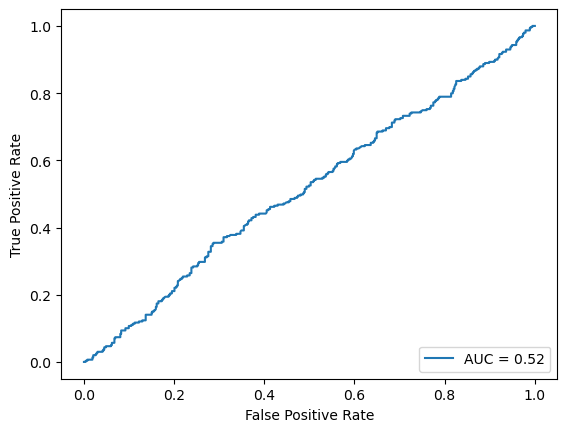

In [35]:
test_performances=torch.load("./test_savings/pooler_only_savings/test_performances.pt",weights_only=False)
targets=test_performances["targets"]
log_probs=test_performances["log_probs"][:,1]
fpr, tpr, thresholds=roc_curve(y_true=targets,y_score=log_probs)
auc_score=roc_auc_score(y_true=targets,y_score=log_probs)
print(f"The AUC score is : {auc_score}")
display=RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=auc_score)
display.plot()
plt.show()

c:\Users\sh032\anaconda3\Lib\site-packages\transformers\modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


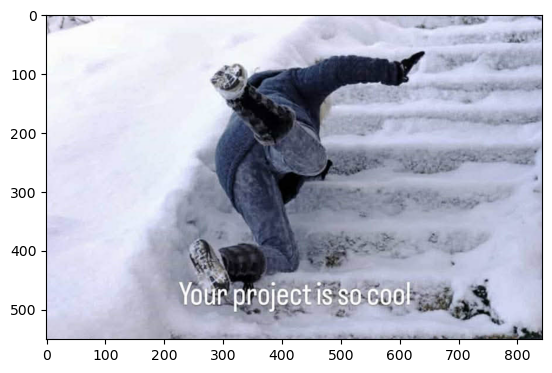

---------------------------
The text of the meme is :
'Your project is so cool'
---------------------------
Classification: The meme is lovely


In [4]:
path="./test_savings/pooler_only_savings"
fc_layer_sizes=[384]
with_clip_image=False
with_clip_text=False
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_text=with_clip_text,with_clip_image=with_clip_image)
model_parameters=torch.load("./train_savings/pooler_only_savings/model_state.pt")
model.load_state_dict(model_parameters)
img_path="..\meme.jpg"
text="Your project is so cool"
with_clip=False
multimodal=False
meme_detector=MemeDetector(model=model,device=device,flava_processor=flava_processor,flava_model=flava_model,clip_model=clip_model,clip_processor=clip_processor)
meme_detector.detection(img_path=img_path,text=text,with_clip=with_clip,multimodal=multimodal)

In [8]:
img=Image.open("..\meme.jpg").convert("RGB")
text="Your project is so cool"
input=flava_processor(img,text,return_tensors="pt")

In [9]:
output=flava_model(input_ids=input["input_ids"],pixel_values=input["pixel_values"],attention_mask=input["attention_mask"])

In [10]:
print(list(output.keys()))

['image_embeddings', 'image_output', 'text_embeddings', 'text_output', 'multimodal_embeddings', 'multimodal_output']


In [25]:
img=Image.open("..\meme.jpg").convert("RGB")
text="Your project is so cool"
input=clip_processor(img,text,return_tensors="pt")

In [27]:
output=clip_model(input_ids=input["input_ids"],pixel_values=input["pixel_values"],attention_mask=input["attention_mask"])

In [28]:
print(list(output.keys()))

['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output']


## Test of the model using pooler embeddings with CLIP embeddings

In [36]:
path="./test_savings/pooler_with_clip_savings"
fc_layer_sizes=[640]
multimodal=False
with_clip_image=True
with_clip_text=True
with_clip=True
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_text=with_clip_text,with_clip_image=with_clip_image)
model_parameters=torch.load("./train_savings/pooler_with_clip_savings/model_state.pt")
model.load_state_dict(model_parameters)
tester=Test(model,device,loss_fn)
f1,accuracy,final_loss,all_targets,all_predictions,log_probs=tester.run_testing(test_dataloader,path=path,multimodal=multimodal,with_clip=with_clip)

2026-05-03 17:10:08.690 | INFO     | modules.model.test:run_testing:29 - Testing run:


2026-05-03 17:10:09.051 | INFO     | modules.model.test:run_testing:84 - Test Loss = 0.6516399280383036
2026-05-03 17:10:09.051 | INFO     | modules.model.test:run_testing:85 - Test F1 Score = 0.6290893188137164
2026-05-03 17:10:09.051 | INFO     | modules.model.test:run_testing:86 - Test Accuracy: = 0.6225961538461539


The AUC score is : 0.6636314506196114


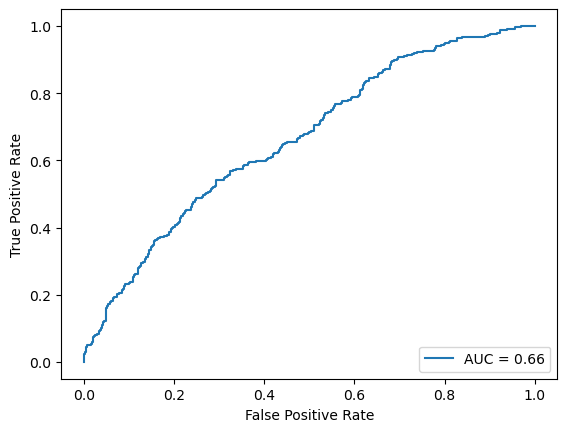

In [37]:
test_performances=torch.load("./test_savings/pooler_with_clip_savings/test_performances.pt",weights_only=False)
targets=test_performances["targets"]
log_probs=test_performances["log_probs"][:,1]
fpr, tpr, thresholds=roc_curve(y_true=targets,y_score=log_probs)
auc_score=roc_auc_score(y_true=targets,y_score=log_probs)
print(f"The AUC score is : {auc_score}")
display=RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=auc_score)
display.plot()
plt.show()

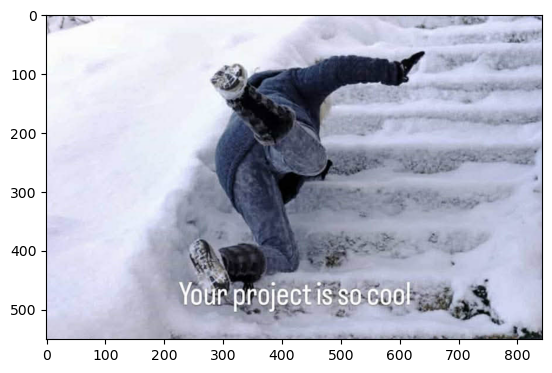

---------------------------
The text of the meme is :
'Your project is so cool'
---------------------------
Classification: The meme is lovely


In [5]:
fc_layer_sizes=[640]
with_clip_image=True
with_clip_text=True
with_clip=True
multimodal=False
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_text=with_clip_text,with_clip_image=with_clip_image)
model_parameters=torch.load("./train_savings/pooler_with_clip_savings/model_state.pt")
model.load_state_dict(model_parameters)
img_path="..\meme.jpg"
text="Your project is so cool"
meme_detector=MemeDetector(model=model,device=device,flava_processor=flava_processor,flava_model=flava_model,clip_model=clip_model,clip_processor=clip_processor)
meme_detector.detection(img_path=img_path,text=text,with_clip=with_clip,multimodal=multimodal)

## Test of the model using multimodal embeddings only

In [41]:
path="./test_savings/multimodal_only_savings"
fc_layer_sizes=[384]
multimodal=True
with_clip_image=False
with_clip_text=False
with_clip=False
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_text=with_clip_text,with_clip_image=with_clip_image)
model_parameters=torch.load("./train_savings/multimodal_only_savings/model_state.pt")
model.load_state_dict(model_parameters)
tester=Test(model,device,loss_fn)
f1,accuracy,final_loss,all_targets,all_predictions,log_probs=tester.run_testing(test_dataloader,path=path,multimodal=multimodal,with_clip=with_clip)

2026-05-03 17:12:38.694 | INFO     | modules.model.test:run_testing:29 - Testing run:
2026-05-03 17:12:38.962 | INFO     | modules.model.test:run_testing:84 - Test Loss = 0.6675997353517092
2026-05-03 17:12:38.962 | INFO     | modules.model.test:run_testing:85 - Test F1 Score = 0.638866842132907
2026-05-03 17:12:38.962 | INFO     | modules.model.test:run_testing:86 - Test Accuracy: = 0.6394230769230769


The AUC score is : 0.649152884227511


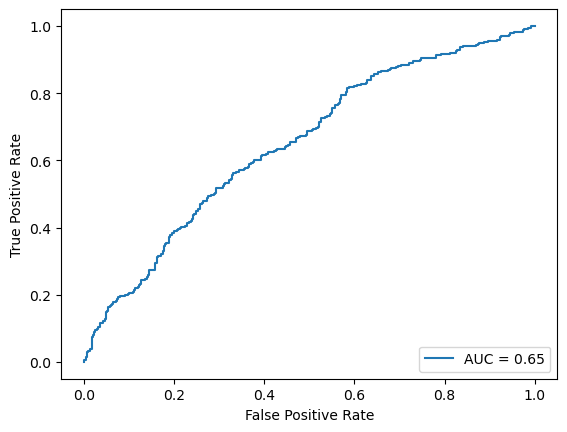

In [42]:
test_performances=torch.load("./test_savings/multimodal_only_savings/test_performances.pt",weights_only=False)
targets=test_performances["targets"]
log_probs=test_performances["log_probs"][:,1]
fpr, tpr, thresholds=roc_curve(y_true=targets,y_score=log_probs)
auc_score=roc_auc_score(y_true=targets,y_score=log_probs)
print(f"The AUC score is : {auc_score}")
display=RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=auc_score)
display.plot()
plt.show()

c:\Users\sh032\anaconda3\Lib\site-packages\transformers\modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


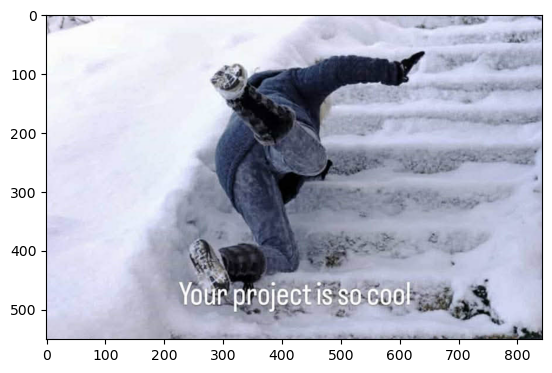

---------------------------
The text of the meme is :
'Your project is so cool'
---------------------------
Classification: The meme is lovely


In [4]:
fc_layer_sizes=[384]
with_clip_image=False
with_clip_text=False
with_clip=False
multimodal=True
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_text=with_clip_text,with_clip_image=with_clip_image)
model_parameters=torch.load("./train_savings/multimodal_only_savings/model_state.pt")
model.load_state_dict(model_parameters)
img_path="..\meme.jpg"
text="Your project is so cool"
meme_detector=MemeDetector(model=model,device=device,flava_processor=flava_processor,flava_model=flava_model,clip_model=clip_model,clip_processor=clip_processor)
meme_detector.detection(img_path=img_path,text=text,with_clip=with_clip,multimodal=multimodal)

## Test of the model using multimodal embeddings with CLIP embeddings

In [45]:
path="./test_savings/multimodal_with_clip_savings"
fc_layer_sizes=[640]
multimodal=True
with_clip_image=True
with_clip_text=True
with_clip=True
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_text=with_clip_text,with_clip_image=with_clip_image)
model_parameters=torch.load("./train_savings/multimodal_with_clip_savings/model_state.pt")
model.load_state_dict(model_parameters)
tester=Test(model,device,loss_fn)
f1,accuracy,final_loss,all_targets,all_predictions,log_probs=tester.run_testing(test_dataloader,path=path,multimodal=multimodal,with_clip=with_clip)

2026-05-03 17:17:36.972 | INFO     | modules.model.test:run_testing:29 - Testing run:
2026-05-03 17:17:37.374 | INFO     | modules.model.test:run_testing:84 - Test Loss = 0.6572496730547684
2026-05-03 17:17:37.374 | INFO     | modules.model.test:run_testing:85 - Test F1 Score = 0.647809795593508
2026-05-03 17:17:37.379 | INFO     | modules.model.test:run_testing:86 - Test Accuracy: = 0.6538461538461539


The AUC score is : 0.6598845030063004


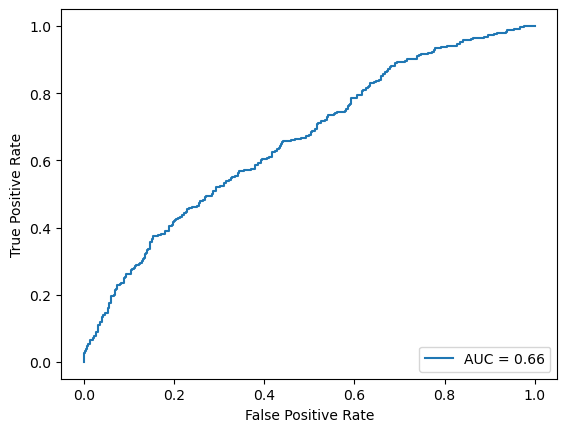

In [46]:
test_performances=torch.load("./test_savings/multimodal_with_clip_savings/test_performances.pt",weights_only=False)
targets=test_performances["targets"]
log_probs=test_performances["log_probs"][:,1]
fpr, tpr, thresholds=roc_curve(y_true=targets,y_score=log_probs)
auc_score=roc_auc_score(y_true=targets,y_score=log_probs)
print(f"The AUC score is : {auc_score}")
display=RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=auc_score)
display.plot()
plt.show()

c:\Users\sh032\anaconda3\Lib\site-packages\transformers\modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


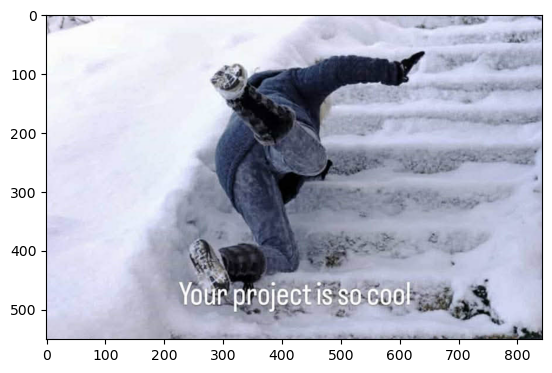

---------------------------
The text of the meme is :
'Your project is so cool'
---------------------------
Classification: The meme is lovely


In [6]:
fc_layer_sizes=[640]
with_clip_image=True
with_clip_text=True
with_clip=True
multimodal=True
model=HeadClassifierFLAVAModel(fc_layer_sizes=fc_layer_sizes,with_clip_text=with_clip_text,with_clip_image=with_clip_image)
model_parameters=torch.load("./train_savings/multimodal_with_clip_savings/model_state.pt")
model.load_state_dict(model_parameters)
img_path="..\meme.jpg"
text="Your project is so cool"
meme_detector=MemeDetector(model=model,device=device,flava_processor=flava_processor,flava_model=flava_model,clip_model=clip_model,clip_processor=clip_processor)
meme_detector.detection(img_path=img_path,text=text,with_clip=with_clip,multimodal=multimodal)